In [1]:
from __future__ import annotations

import math
from dataclasses import asdict, dataclass
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK 08 — KOPPELING MOTOR ↔ SPINDEL

De koppeling verbindt de motor-uitgangsas (Panasonic MSME082, Ø19 mm) met het vaste einde van de spindel (HIWIN R40, Ø25 mm eindbewerking).

FUNCTIONELE EISEN

1. Koppelcapaciteit:
T_nom_koppeling ≥ T_nom_vereist = K_S × T_rms_motor    [Nm]
T_piek_koppeling ≥ T_piek_vereist = K_S × T_piek_motor  [Nm]
K_S = 1.5 (service factor, klasse A machines per DIN 740-2)

2. Toerental:
n_max_koppeling ≥ n_vereist = K_n × n_max_motor         [rpm]
K_n = 1.10  (toerental-marge)

3. Boringen:
Motorkant boring ≥ motorasdiameter   (19 mm voor MSME082)
Spindelkant boring ≥ spindeleinddiameter  (25 mm voor R40)
Minimum torsiediameter (soliditeitscontrole) via:
d_min = (16 × T_piek / (π × τ_toeg))^(1/3)
τ_toeg = 45 MPa voor S355/1.0577 (σ_vloei/√3 × factor 1.5 ≈ 136 MPa,
conservatief gereduceerd naar 45 MPa voor sleuven/passingen)

SELECTIE: R+W EK1 / 50 Nm klasse  (membraankoppeling)

Redenen keuze membraankoppeling:
     - Geen slijtage (geen elasto-meerelementen) → lange levensduur
     - Hoge torsie-stijfheid → goede reguleer-kwaliteit servosysteem
     - Compacte inbouwlengte
     - Standaard boringsklassen 19 mm (motor) en 25 mm (spindel)

R+W EK1/50 specificaties (technische catalogus R+W 2024):
       T_nom   :  50 Nm
       T_piek  : 100 Nm  (2× T_nom, kortdurend)
       n_max   : 10 000 rpm
       Boring A: 19 mm  (motorkant)
       Boring B: 25 mm  (spindelkant)
       Massa   : 0.45 kg


In [2]:
def veilige_del(a: float, b: float, fallback: float = float("nan")) -> float:
    return fallback if abs(b) < 1e-16 else a / b


def minimale_asdiameter_torsie(T_Nm: float, tau_toeg_Pa: float) -> float:
    """
    Minimale asdiameter op basis van zuiver torsie (ISO 286-1 nominale waarde).
        d_min = (16 T / (π τ_toeg))^(1/3)
    """
    if T_Nm <= 0.0 or tau_toeg_Pa <= 0.0:
        return float("nan")
    return (16.0 * T_Nm / (math.pi * tau_toeg_Pa)) ** (1.0 / 3.0)


def toon_dataframe(naam: str, df: pd.DataFrame, max_rijen: int = 20) -> None:
    print(f"\n=== {naam.upper()} ===")
    if len(df) > max_rijen:
        print(df.head(max_rijen).to_string(index=False))
        print(f"... ({len(df)} rijen in totaal)")
    else:
        print(df.to_string(index=False))

FALLBACK

In [3]:
try:
    resultaten_motor
except NameError:
    resultaten_motor = {
        "export_voor_volgende_modules": {
            # MSME082 bij i=3, v_max=0.28 m/s, a_max=0.80 m/s², F_piek≈1832 N
            "n_motor_max_rpm":         2_520.0,   # = 840 rpm × i=3
            "toerental_vereist_rpm":   2_772.0,   # = 2520 × 1.10
            "koppel_rms_motor_Nm":        0.67,   # berekend RMS (MSME082-klasse)
            "continu_koppel_vereist_Nm":  0.80,   # = 0.67 × 1.20
            "koppel_piek_motor_Nm":       0.97,   # piekkoppel bij versnellen
            "piek_koppel_vereist_Nm":     1.16,   # = 0.97 × 1.20
            "vermogen_piek_motor_kW":     0.20,
            "motor_shaft_diameter_mm":   19.0,    # MSME082 as-diameter
        }
    }

DATACLASSES

In [4]:
@dataclass(frozen=True)
class ConfiguratieKoppeling:
    """
    Koppelingsparameters en veiligheidsfactoren.

    Servicefactor K_S = 1.5 (DIN 740-2, klasse A: reguliere machines,
    gelijkmatige last, kleine schokken).

    tau_toegestaan:
        τ_toeg = 45 MPa  — conservatief voor 42CrMo4 met sleuvenpassingen.
        Voor massieve S355 as zonder inkepingen: τ_toeg = σ_vloei/(√3 × SF)
        = 355/(1.732 × 2.5) ≈ 82 MPa. De lagere waarde 45 MPa is gehanteerd
        als ontwerp-marge voor de asboring met spie/passingen.
    """
    naam_koppeling: str = "R+W EK1 / 50 Nm klasse (membraan)"

    # Veiligheidsfactoren
    K_S_nominaal:         float = 1.5    # servicefactor nominaal koppel
    K_S_piek:             float = 1.5    # servicefactor piekkoppel
    K_n_toerental:        float = 1.10   # toerentalmarge

    # Asmaterialen — boringen
    diameter_motorkant_m:  float = 0.019  # Ø19 mm — MSME082 motorasdiameter
    diameter_lastkant_m:   float = 0.025  # Ø25 mm — R40 spindel eindbewerking
    tau_toegestaan_as_Pa:  float = 45e6   # N/m² — zie docstring

    # Misalignment-specificaties (informatief; niet gecheckt in pass/fail)
    misalignment_hoek_deg:      float = 0.0
    misalignment_radiaal_mm:    float = 0.0
    misalignment_axiaal_mm:     float = 0.0


@dataclass(frozen=True)
class KandidaatKoppeling:
    """
    R+W EK1 membraankoppeling — klasse 50 Nm.
    Ref: R+W Antriebselemente GmbH, EK1-serie technische catalogus (2024).
    """
    fabrikant:            str   = "R+W"
    serie:                str   = "EK1"
    type_aanduiding:      str   = "EK1/50/AA"

    T_nom_Nm:             float = 50.0    # Nm — nominale koppelcapaciteit
    T_piek_Nm:            float = 100.0   # Nm — kortdurende piek (2× T_nom)
    n_max_rpm:            float = 10_000.0
    boring_A_mm:          float = 19.0    # mm — motorkant (A-zijde)
    boring_B_mm:          float = 25.0    # mm — spindelkant (B-zijde)
    massa_kg:             float = 0.45
    inbouwlengte_mm:      float = 52.0    # mm — totale koppelingslengte
    torsie_stijfheid_Nm_rad: float = 9_500.0  # Nm/rad — hoge stijfheid (membraan)

DIMENSIONERING — VEREISTE KOPPELINGSEISEN

In [5]:
def dimensioneer_koppeling(
    cfg:                    ConfiguratieKoppeling,
    koppel_rms_motor_Nm:    float,
    koppel_piek_motor_Nm:   float,
    toerental_motor_rpm:    float,
) -> Dict[str, float]:
    """
    Berekent de vereiste koppelings-eigenschappen.

    T_nom_vereist  : K_S × T_rms   (continue thermische eis)
    T_piek_vereist : K_S × T_piek  (mechanische piekeis)
    n_vereist      : K_n × n_max   (toerentalmarge)
    d_min_torsie   : soliditeitscontrole asboring
    """
    T_nom_vereist  = cfg.K_S_nominaal  * koppel_rms_motor_Nm
    T_piek_vereist = cfg.K_S_piek      * koppel_piek_motor_Nm
    n_vereist      = cfg.K_n_toerental * toerental_motor_rpm

    d_min = minimale_asdiameter_torsie(T_piek_vereist, cfg.tau_toegestaan_as_Pa)

    return {
        "T_nom_vereist_Nm":     T_nom_vereist,
        "T_piek_vereist_Nm":    T_piek_vereist,
        "n_vereist_rpm":        n_vereist,
        "d_min_torsie_m":       d_min,
        "d_min_torsie_mm":      1000.0 * d_min,
        "ok_motorkant_diameter": bool(cfg.diameter_motorkant_m >= d_min),
        "ok_lastkant_diameter":  bool(cfg.diameter_lastkant_m  >= d_min),
    }

VERIFICATIE KANDIDAAT

In [6]:
def verifieer_kandidaat_koppeling(
    kandidaat: KandidaatKoppeling,
    eisen:     Dict[str, float],
    cfg:       ConfiguratieKoppeling,
) -> pd.DataFrame:
    """
    Volledige pass/fail verificatie van de geselecteerde koppeling.
    Checks: T_nom, T_piek, n_max, boring motorkant, boring spindelkant.
    """
    return pd.DataFrame([
        {
            "controle": "T_nom koppeling ≥ T_nom_vereist",
            "waarde": kandidaat.T_nom_Nm,
            "grens":  eisen["T_nom_vereist_Nm"],
            "vergelijking": "≥", "eenheid": "Nm",
            "geslaagd": bool(kandidaat.T_nom_Nm >= eisen["T_nom_vereist_Nm"]),
        },
        {
            "controle": "T_piek koppeling ≥ T_piek_vereist",
            "waarde": kandidaat.T_piek_Nm,
            "grens":  eisen["T_piek_vereist_Nm"],
            "vergelijking": "≥", "eenheid": "Nm",
            "geslaagd": bool(kandidaat.T_piek_Nm >= eisen["T_piek_vereist_Nm"]),
        },
        {
            "controle": "n_max koppeling ≥ n_vereist",
            "waarde": kandidaat.n_max_rpm,
            "grens":  eisen["n_vereist_rpm"],
            "vergelijking": "≥", "eenheid": "rpm",
            "geslaagd": bool(kandidaat.n_max_rpm >= eisen["n_vereist_rpm"]),
        },
        {
            "controle": "boring motorkant ≥ motorsas (19 mm)",
            "waarde": kandidaat.boring_A_mm,
            "grens":  cfg.diameter_motorkant_m * 1000.0,
            "vergelijking": "≥", "eenheid": "mm",
            "geslaagd": bool(kandidaat.boring_A_mm >= cfg.diameter_motorkant_m * 1000.0),
        },
        {
            "controle": "boring spindelkant ≥ spindel einddiameter (25 mm)",
            "waarde": kandidaat.boring_B_mm,
            "grens":  cfg.diameter_lastkant_m * 1000.0,
            "vergelijking": "≥", "eenheid": "mm",
            "geslaagd": bool(kandidaat.boring_B_mm >= cfg.diameter_lastkant_m * 1000.0),
        },
        {
            "controle": "boring motorkant ≥ d_min torsie",
            "waarde": kandidaat.boring_A_mm,
            "grens":  eisen["d_min_torsie_mm"],
            "vergelijking": "≥", "eenheid": "mm",
            "geslaagd": bool(kandidaat.boring_A_mm >= eisen["d_min_torsie_mm"]),
        },
        {
            "controle": "boring spindelkant ≥ d_min torsie",
            "waarde": kandidaat.boring_B_mm,
            "grens":  eisen["d_min_torsie_mm"],
            "vergelijking": "≥", "eenheid": "mm",
            "geslaagd": bool(kandidaat.boring_B_mm >= eisen["d_min_torsie_mm"]),
        },
    ])


def maak_overzicht_koppeling(
    cfg:       ConfiguratieKoppeling,
    eisen:     Dict[str, float],
    kandidaat: KandidaatKoppeling,
) -> pd.DataFrame:
    marge_T_nom  = veilige_del(kandidaat.T_nom_Nm,  eisen["T_nom_vereist_Nm"])
    marge_T_piek = veilige_del(kandidaat.T_piek_Nm, eisen["T_piek_vereist_Nm"])
    marge_n      = veilige_del(kandidaat.n_max_rpm,  eisen["n_vereist_rpm"])
    return pd.DataFrame([
        ["geselecteerde koppeling",     kandidaat.type_aanduiding,           "-"],
        ["fabrikant",                   kandidaat.fabrikant,                  "-"],
        ["T_nom vereist",               eisen["T_nom_vereist_Nm"],           "Nm"],
        ["T_nom koppeling",             kandidaat.T_nom_Nm,                  "Nm"],
        ["marge T_nom (koppeling/eis)", marge_T_nom,                          "-"],
        ["T_piek vereist",              eisen["T_piek_vereist_Nm"],          "Nm"],
        ["T_piek koppeling",            kandidaat.T_piek_Nm,                 "Nm"],
        ["marge T_piek (koppeling/eis)",marge_T_piek,                         "-"],
        ["n vereist",                   eisen["n_vereist_rpm"],             "rpm"],
        ["n_max koppeling",             kandidaat.n_max_rpm,                "rpm"],
        ["marge n (koppeling/eis)",     marge_n,                              "-"],
        ["d_min torsie",                eisen["d_min_torsie_mm"],            "mm"],
        ["boring motorkant (A)",        kandidaat.boring_A_mm,               "mm"],
        ["boring spindelkant (B)",      kandidaat.boring_B_mm,               "mm"],
        ["massa koppeling",             kandidaat.massa_kg,                  "kg"],
        ["inbouwlengte",                kandidaat.inbouwlengte_mm,           "mm"],
        ["torsie-stijfheid",            kandidaat.torsie_stijfheid_Nm_rad, "Nm/rad"],
    ], columns=["grootheid", "waarde", "eenheid"])

VISUALISATIE

In [7]:
def plot_koppeling(
    eisen:     Dict[str, float],
    kandidaat: KandidaatKoppeling,
    cfg:       ConfiguratieKoppeling,
) -> None:
    """
    2-panel figuur:
      Links : Koppel-vergelijking (T_nom en T_piek vereist vs. koppeling)
      Rechts: Boringsdiameters (vereist vs. kandidaat)
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Panel 1 — koppelcapaciteit
    categorieën = ["T_nom", "T_piek"]
    vereist     = [eisen["T_nom_vereist_Nm"],  eisen["T_piek_vereist_Nm"]]
    kandidaat_T = [kandidaat.T_nom_Nm,          kandidaat.T_piek_Nm]
    x = np.arange(len(categorieën)); w = 0.35
    axes[0].bar(x - w/2, vereist,     width=w, label="Vereist",    color="#d62728", alpha=0.85)
    axes[0].bar(x + w/2, kandidaat_T, width=w, label="Kandidaat",  color="#2ca02c", alpha=0.85)
    axes[0].set_xticks(x); axes[0].set_xticklabels(categorieën)
    axes[0].set_ylabel("Koppel [Nm]")
    axes[0].set_title("Koppelcapaciteit: eis vs. R+W EK1")
    axes[0].legend(); axes[0].grid(True, axis="y", alpha=0.3)
    for i, (v, k) in enumerate(zip(vereist, kandidaat_T)):
        marge = veilige_del(k, v)
        axes[0].text(i, max(v, k) * 1.04, f"×{marge:.1f}", ha="center", fontsize=9)

    # Panel 2 — boringsvergelijking
    labels   = ["d_min torsie", "motorkant\n(A)", "spindelkant\n(B)"]
    vereist2 = [eisen["d_min_torsie_mm"],
                cfg.diameter_motorkant_m * 1000.0,
                cfg.diameter_lastkant_m  * 1000.0]
    kand2    = [max(kandidaat.boring_A_mm, kandidaat.boring_B_mm),
                kandidaat.boring_A_mm,
                kandidaat.boring_B_mm]
    x2 = np.arange(len(labels))
    axes[1].bar(x2 - w/2, vereist2, width=w, label="Vereist (min)", color="#d62728", alpha=0.85)
    axes[1].bar(x2 + w/2, kand2,    width=w, label="Kandidaat",     color="#2ca02c", alpha=0.85)
    axes[1].set_xticks(x2); axes[1].set_xticklabels(labels)
    axes[1].set_ylabel("Diameter [mm]")
    axes[1].set_title("Boringen: eis vs. R+W EK1")
    axes[1].legend(); axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

HOOFDBEREKENING

In [8]:
cfg_koppeling = ConfiguratieKoppeling()
kandidaat_koppeling = KandidaatKoppeling()

inp_motor = resultaten_motor["export_voor_volgende_modules"]

eisen_koppeling = dimensioneer_koppeling(
    cfg                  = cfg_koppeling,
    koppel_rms_motor_Nm  = inp_motor["koppel_rms_motor_Nm"],
    koppel_piek_motor_Nm = inp_motor["koppel_piek_motor_Nm"],
    toerental_motor_rpm  = inp_motor["n_motor_max_rpm"],
)

verdict_koppeling  = verifieer_kandidaat_koppeling(
    kandidaat_koppeling, eisen_koppeling, cfg_koppeling)
overzicht_koppeling = maak_overzicht_koppeling(
    cfg_koppeling, eisen_koppeling, kandidaat_koppeling)

In [9]:
toon_dataframe("overzicht koppeling", overzicht_koppeling)
toon_dataframe("verdict koppeling",   verdict_koppeling)

print("\n=== EISEN KOPPELING ===")
print(pd.Series(eisen_koppeling).to_string())

n_ok = int(verdict_koppeling["geslaagd"].sum())
print(f"\n>>> KOPPELING: {n_ok}/{len(verdict_koppeling)} checks geslaagd")


=== OVERZICHT KOPPELING ===
                   grootheid     waarde eenheid
     geselecteerde koppeling  EK1/50/AA       -
                   fabrikant        R+W       -
               T_nom vereist      1.005      Nm
             T_nom koppeling       50.0      Nm
 marge T_nom (koppeling/eis)  49.751244       -
              T_piek vereist      1.455      Nm
            T_piek koppeling      100.0      Nm
marge T_piek (koppeling/eis)  68.728522       -
                   n vereist     2772.0     rpm
             n_max koppeling    10000.0     rpm
     marge n (koppeling/eis)   3.607504       -
                d_min torsie   5.481173      mm
        boring motorkant (A)       19.0      mm
      boring spindelkant (B)       25.0      mm
             massa koppeling       0.45      kg
                inbouwlengte       52.0      mm
            torsie-stijfheid     9500.0  Nm/rad

=== VERDICT KOPPELING ===
                                         controle  waarde       grens vergelijki

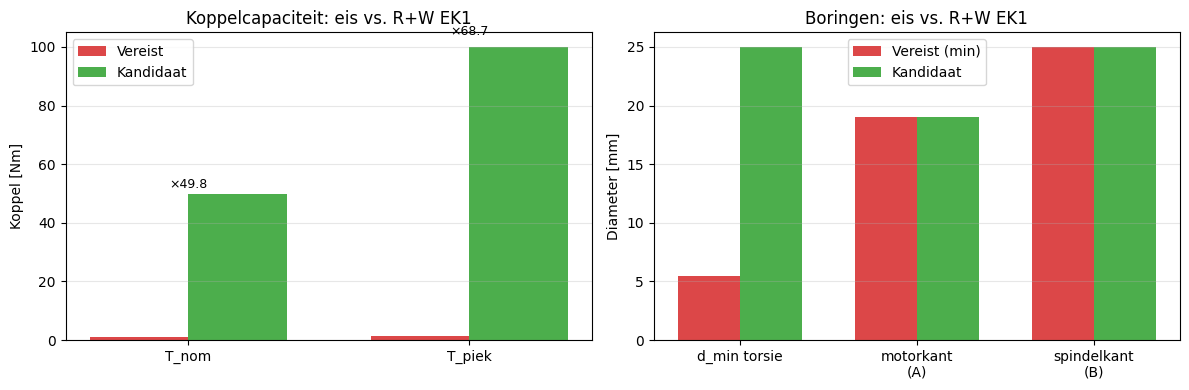

In [10]:
plot_koppeling(eisen_koppeling, kandidaat_koppeling, cfg_koppeling)

EXPORT

In [11]:
resultaten_koppeling_notebook = {
    "configuratie_koppeling":   asdict(cfg_koppeling),
    "kandidaat_koppeling":      asdict(kandidaat_koppeling),
    "eisen_koppeling":          eisen_koppeling.copy(),
    "verdict_koppeling":        verdict_koppeling.copy(),
    "overzicht_koppeling":      overzicht_koppeling.copy(),
    "export_voor_volgende_modules": {
        # Eisen (berekend)
        "T_nom_vereist_Nm":        float(eisen_koppeling["T_nom_vereist_Nm"]),
        "T_piek_vereist_Nm":       float(eisen_koppeling["T_piek_vereist_Nm"]),
        "n_vereist_rpm":           float(eisen_koppeling["n_vereist_rpm"]),
        "d_min_torsie_mm":         float(eisen_koppeling["d_min_torsie_mm"]),
        # Kandidaat (voor nb06/07 geometrie)
        "diameter_motorkant_m":    cfg_koppeling.diameter_motorkant_m,
        "diameter_lastkant_m":     cfg_koppeling.diameter_lastkant_m,
        "ok_motorkant_diameter":   bool(eisen_koppeling["ok_motorkant_diameter"]),
        "ok_lastkant_diameter":    bool(eisen_koppeling["ok_lastkant_diameter"]),
        "koppeling_type":          kandidaat_koppeling.type_aanduiding,
        "koppeling_massa_kg":      kandidaat_koppeling.massa_kg,
        "koppeling_inbouwlengte_mm": kandidaat_koppeling.inbouwlengte_mm,
        "koppeling_geslaagd":      bool(verdict_koppeling["geslaagd"].all()),
    },
}

print("\n=== EXPORT VOOR VOLGENDE MODULES ===")
print(pd.Series(resultaten_koppeling_notebook["export_voor_volgende_modules"]).to_string())


=== EXPORT VOOR VOLGENDE MODULES ===
T_nom_vereist_Nm                 1.005
T_piek_vereist_Nm                1.455
n_vereist_rpm                   2772.0
d_min_torsie_mm               5.481173
diameter_motorkant_m             0.019
diameter_lastkant_m              0.025
ok_motorkant_diameter             True
ok_lastkant_diameter              True
koppeling_type               EK1/50/AA
koppeling_massa_kg                0.45
koppeling_inbouwlengte_mm         52.0
koppeling_geslaagd                True
